In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

# TensorFlow & Keras for building and training CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# NumPy for numerical operations
import numpy as np

# Matplotlib for visualization
import matplotlib.pyplot as plt

#REAL-TIME IMAGE UPLOAD
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [2]:
# ==============================
# 2. LOAD DATASET
# ==============================

# Fashion MNIST dataset contains 28x28 grayscale images of clothing
# It returns:
# x_train, y_train -> training data
# x_test, y_test   -> testing data
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
# Class labels for reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
# ==============================
# 3. DATA PREPROCESSING
# ==============================

# Normalize pixel values (0–255 → 0–1)
# This helps faster convergence and better training
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# Reshape data to (28, 28, 1)
# CNN expects 3D input: height, width, channels
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
# Convert labels to categorical (one-hot encoding)
# Needed for categorical crossentropy
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [7]:
# ==============================
# 4. DEFINE CNN MODEL
# ==============================

model = keras.Sequential()

# ---- Convolution Layer 1 ----
# 32 filters of size 3x3
# Extracts low-level features like edges
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# ---- Pooling Layer ----
# Reduces spatial size → less computation
model.add(layers.MaxPooling2D((2,2)))

# ---- Convolution Layer 2 ----
# More filters → deeper feature extraction
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# ---- Pooling Layer ----
model.add(layers.MaxPooling2D((2,2)))

# ---- Dropout Layer ----
# Prevents overfitting by randomly dropping neurons
model.add(layers.Dropout(0.25))

# ---- Flatten Layer ----
# Converts 2D feature maps → 1D vector
model.add(layers.Flatten())

# ---- Fully Connected Layer ----
# Learns complex patterns
model.add(layers.Dense(128, activation='relu'))

# ---- Dropout Layer ----
model.add(layers.Dropout(0.5))

# ---- Output Layer ----
# 10 neurons (one for each class)
# Softmax gives probability distribution
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# ==============================
# 5. COMPILE MODEL
# ==============================

# Loss Function: categorical_crossentropy → for multi-class classification
# Optimizer: Adam → adaptive learning
# Metric: accuracy → performance measure
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
# ==============================
# 6. TRAIN MODEL
# ==============================

# Train the model
# epochs → number of times dataset is passed
# batch_size → number of samples per update
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7734 - loss: 0.6271 - val_accuracy: 0.8588 - val_loss: 0.3927
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8490 - loss: 0.4164 - val_accuracy: 0.8767 - val_loss: 0.3361
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8695 - loss: 0.3630 - val_accuracy: 0.8871 - val_loss: 0.3001
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8819 - loss: 0.3260 - val_accuracy: 0.8975 - val_loss: 0.2793
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8881 - loss: 0.3058 - val_accuracy: 0.8994 - val_loss: 0.2710
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8948 - loss: 0.2886 - val_accuracy: 0.9036 - val_loss: 0.2562
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8990 - loss: 0.2744 - val_accuracy: 0.9069 - val_loss: 0.2518
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9025 - loss: 0.2625 - val_accuracy: 0.

In [10]:
# ==============================
# 7. EVALUATE MODEL
# ==============================

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9131 - loss: 0.2514
Test Accuracy: 0.913100004196167
Test Loss: 0.25138768553733826


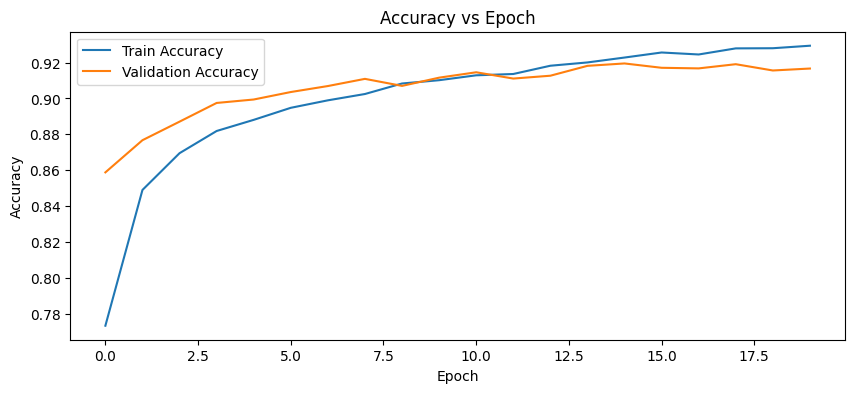

In [11]:
# ==============================
# 8. PLOT TRAINING GRAPHS
# ==============================

# Accuracy graph
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

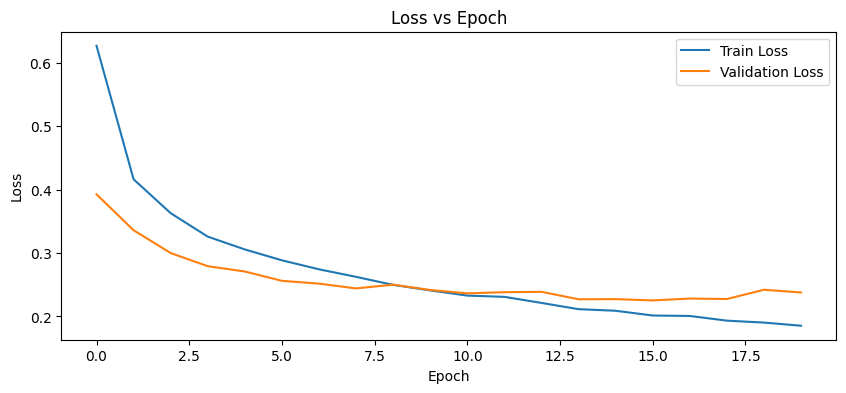

In [12]:
# Loss graph
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
# ==============================
# 9. MAKE PREDICTIONS
# ==============================

# Predict on test images
predictions = model.predict(x_test)

# Convert probabilities → class index
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


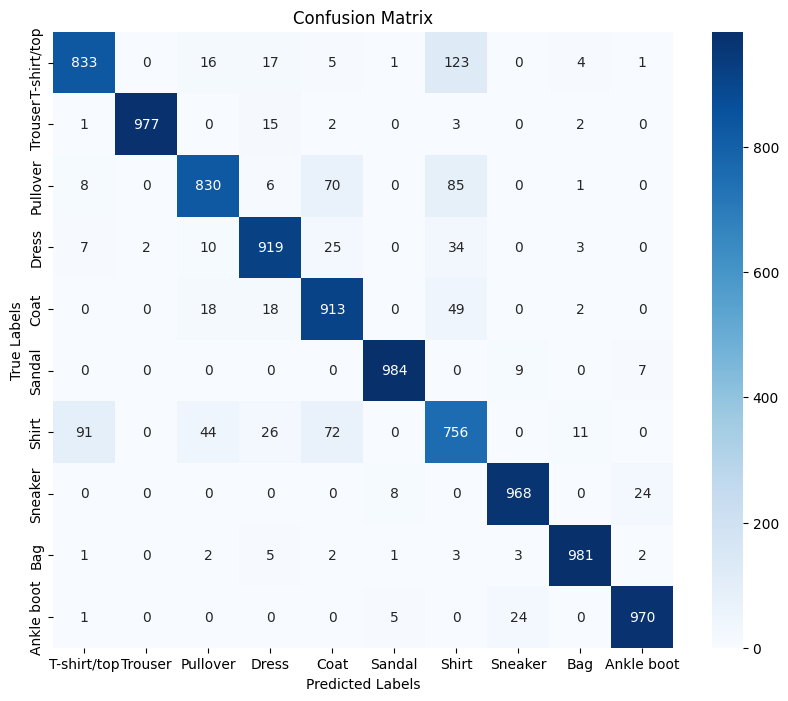

In [14]:
# ==============================
# 10. CONFUSION MATRIX
# ==============================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predicted labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

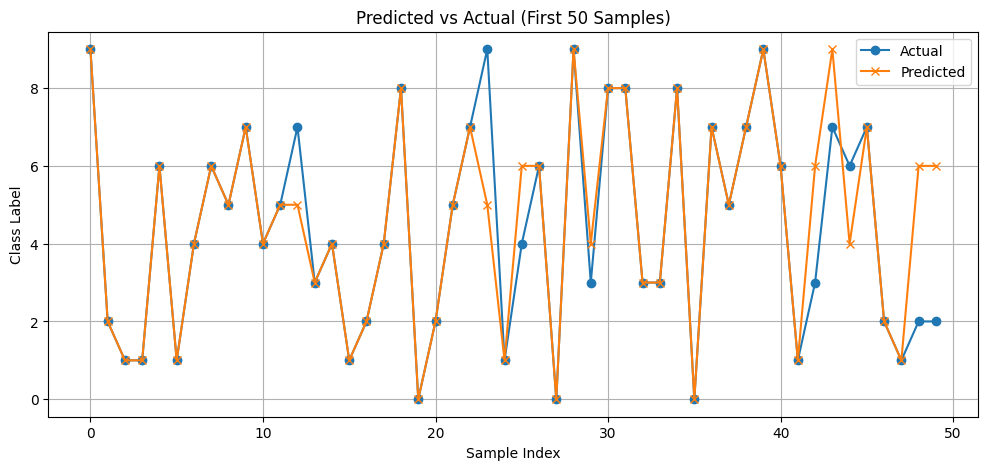

In [15]:
# ==============================
# 11. PREDICTED vs ACTUAL
# ==============================

plt.figure(figsize=(12,5))

# Show first 50 samples comparison
plt.plot(y_true[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')

plt.title("Predicted vs Actual (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.legend()
plt.grid()

plt.show()

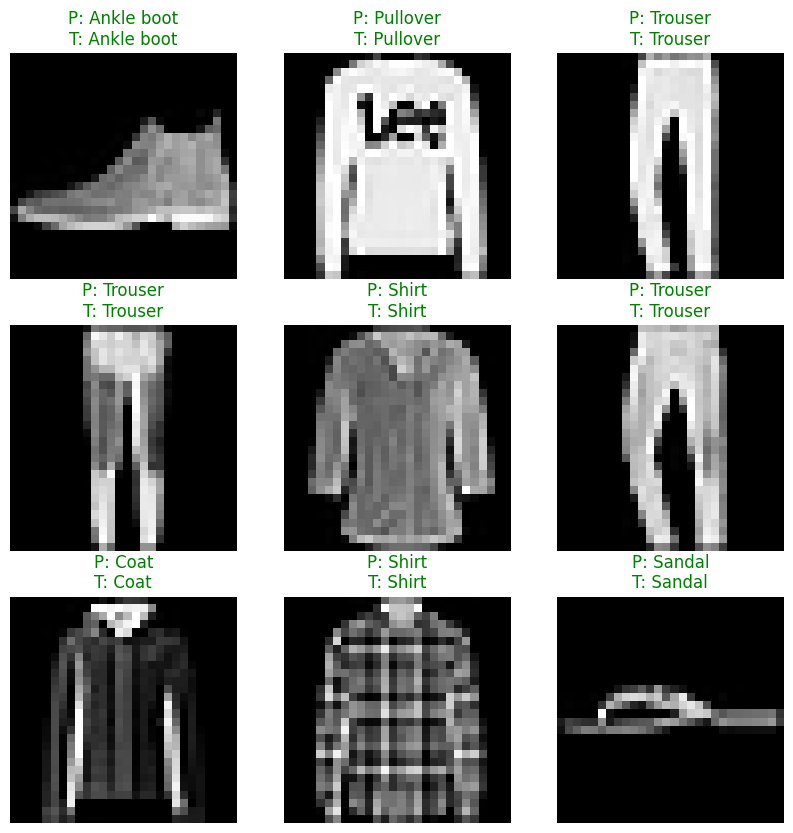

In [16]:
# ==============================
# 12. VISUAL GRID WITH COLORS
# ==============================

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    pred = class_names[y_pred[i]]
    true = class_names[y_true[i]]

    color = 'green' if pred == true else 'red'

    plt.title(f"P: {pred}\nT: {true}", color=color)
    plt.axis('off')

plt.show()

In [17]:
import matplotlib.pyplot as plt

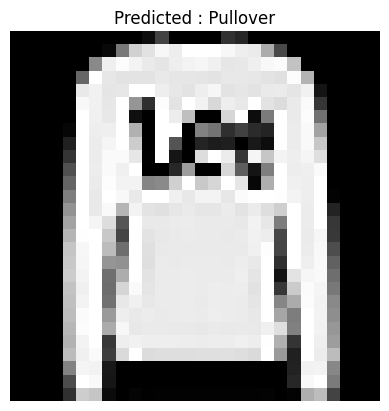

Actual Label    : Pullover
Predicted Label : Pullover


In [18]:
# ==============================
# Step 13: SHOW PREDICTION EXAMPLE
# ==============================

index = 1

plt.imshow(x_test[index], cmap='gray')
plt.title("Predicted : " + class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

print("Actual Label    :", class_names[np.argmax(y_test[index])])
print("Predicted Label :", class_names[np.argmax(predictions[index])])

Saving test_img_2.png to test_img_2.png


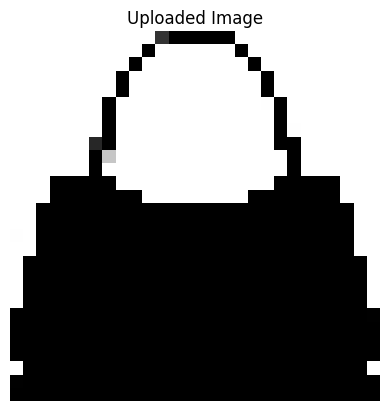

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Predicted Class: Bag
Confidence: 100.0 %


In [19]:
# ==============================
# 14. REAL-TIME IMAGE UPLOAD (COLAB)
# ==============================

def upload_and_predict():
    # Upload file from local system
    uploaded = files.upload()

    for file_name in uploaded.keys():
        # Load image (grayscale, resize 28x28)
        img = image.load_img(file_name, color_mode='grayscale', target_size=(28, 28))

        # Show image
        plt.imshow(img, cmap='gray')
        plt.title("Uploaded Image")
        plt.axis('off')
        plt.show()

        # Convert to array
        img_array = image.img_to_array(img)

        # Normalize
        img_array = img_array / 255.0

        #Fixes white/black inversion issue
        img_array = 1 - img_array

        # Reshape
        img_array = img_array.reshape(1, 28, 28, 1)

        # Predict
        prediction = model.predict(img_array)

        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)

        print("Predicted Class:", class_names[predicted_class])
        print("Confidence:", round(confidence * 100, 2), "%")

# Run this function
upload_and_predict()